# 01 — Data Exploration & Class Grouping

Loads the TDC DrugBank DDI dataset, explores it, and merges rare interaction types (<100 samples) into an `Other` bucket. Produces `df_grouped.pkl` for the next notebook plus the before/after class-distribution chart.

In [11]:
import sys
sys.path.append('..')

import pandas as pd
from tdc.multi_pred import DDI

data = DDI(name='DrugBank', path='../data')
df = data.get_data()
print(df.shape)
df.head()


Found local copy...
Loading...
Done!


(191808, 5)


,Drug1_ID,Drug1,Drug2_ID,Drug2,Y
0,DB04571,CC1=CC2=CC3=C(OC(=O)C=C3C)C(C)=C2O1,DB00460,COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...,1
1,DB00855,NCC(=O)CCC(O)=O,DB00460,COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...,1
2,DB09536,O=[Ti]=O,DB00460,COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...,1
3,DB01600,CC(C(O)=O)C1=CC=C(S1)C(=O)C1=CC=CC=C1,DB00460,COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...,1
4,DB09000,CC(CN(C)C)CN1C2=CC=CC=C2SC2=C1C=C(C=C2)C#N,DB00460,COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...,1


## Explore the raw dataset

In [12]:
print(df.shape)
print(df['Y'].value_counts())
print(df.isnull().sum())
df['Drug1'].sample(5).tolist()


(191808, 5)
Y
49    60751
47    34360
73    23779
75     9470
60     8397
      ...  
28       11
1        11
52       10
26        7
42        6
Name: count, Length: 86, dtype: int64
Drug1_ID    0
Drug1       0
Drug2_ID    0
Drug2       0
Y           0
dtype: int64


['COC1=CC=CC2=C1C(=O)C1=C(O)C3=C(C[C@](O)(C[C@@H]3O[C@H]3C[C@H](N)[C@H](O)[C@H](C)O3)C(=O)CO)C(O)=C1C2=O',
 'CC(CC1=CC=C(O)C=C1)NCC(O)C1=CC(O)=CC(O)=C1',
 'CCOC(=O)CN[C@@H](C(=O)N1CC[C@H]1C(=O)NCC1=CC=C(C=C1)C(\\N)=N\\O)C1CCCCC1',
 'COC1=CN=C(O[C@@H]2C[C@H](N(C2)C(=O)[C@@H](NC(=O)OC(C)(C)C)C(C)(C)C)C(=O)N[C@@]2(C[C@H]2C=C)C(=O)NS(=O)(=O)C2CC2)C2=C1C=CC(Cl)=C2',
 'ClC1=CC2=C(OC(=O)N2)C=C1']

## Group rare interaction types

Classes with fewer than 100 samples are merged into a single `Other` bucket — this keeps 53 of the original 86 classes distinct while ensuring every kept class has enough samples to survive a stratified train/val/test split. See `group_rare_labels` in `src/model.py` for the reusable logic.

In [13]:
from src.model import group_rare_labels

df['Y_grouped'] = group_rare_labels(df, y_col='Y', threshold=100)
print(df['Y_grouped'].value_counts())
print(f"\nTotal classes: {df['Y_grouped'].nunique()}")


Y_grouped
49       60751
47       34360
73       23779
75        9470
60        8397
70        7786
20        6140
16        5413
4         5011
6         3160
37        3089
9         2109
72        1825
54        1277
Other     1275
83        1204
58        1043
32        1011
27         936
67         930
64         803
25         716
71         673
57         664
10         629
30         616
76         558
77         538
3          518
61         498
33         442
21         428
74         422
85         372
14         361
82         355
53         336
29         324
2          323
11         312
34         312
5          309
40         300
69         280
68         278
8          244
12         238
15         202
24         180
39         148
66         128
55         118
19         109
81         108
Name: count, dtype: int64

Total classes: 54


## Sanity checks

In [14]:
# Row count integrity
assert df['Y_grouped'].value_counts().sum() == len(df)
assert df['Y_grouped'].isnull().sum() == 0
print("Row count check passed")

print(f"Total classes: {df['Y_grouped'].nunique()}")
print(f"Min class size: {df['Y_grouped'].value_counts().min()}")


Row count check passed
Total classes: 54
Min class size: 108


In [15]:
from tdc.utils import get_label_map

label_map = get_label_map(name='DrugBank', task='DDI', path='../data')

class_counts = df['Y'].value_counts()
rare_labels = class_counts[class_counts < 100].index
print("Labels merged into 'Other':")
for label_id in rare_labels:
    print(f"  {label_id}: {label_map[label_id]} ({class_counts[label_id]} samples)")


Labels merged into 'Other':
  36: #Drug1 may increase the antipsychotic activities of #Drug2. (94 samples)
  22: #Drug1 may increase the adverse neuromuscular activities of #Drug2. (94 samples)
  17: #Drug1 may decrease the neuromuscular blocking activities of #Drug2. (83 samples)
  51: #Drug1 may increase the hypercalcemic activities of #Drug2. (83 samples)
  18: #Drug1 can cause an increase in the absorption of #Drug2 resulting in an increased serum concentration and potentially a worsening of adverse effects. (82 samples)
  48: #Drug1 may increase the myopathic rhabdomyolysis activities of #Drug2. (69 samples)
  35: #Drug1 may increase the neurotoxic activities of #Drug2. (69 samples)
  84: #Drug1 may increase the vasopressor activities of #Drug2. (65 samples)
  80: #Drug1 may increase the hepatotoxic activities of #Drug2. (64 samples)
  23: #Drug1 may increase the stimulatory activities of #Drug2. (56 samples)
  13: The absorption of #Drug2 can be decreased when combined with #Drug

In [16]:
# Confirm the largest class was left untouched
assert (df.loc[df['Y'] == 49, 'Y_grouped'] == 49).all()
print("Largest class unchanged: OK")


Largest class unchanged: OK


## Class distribution — before vs after grouping

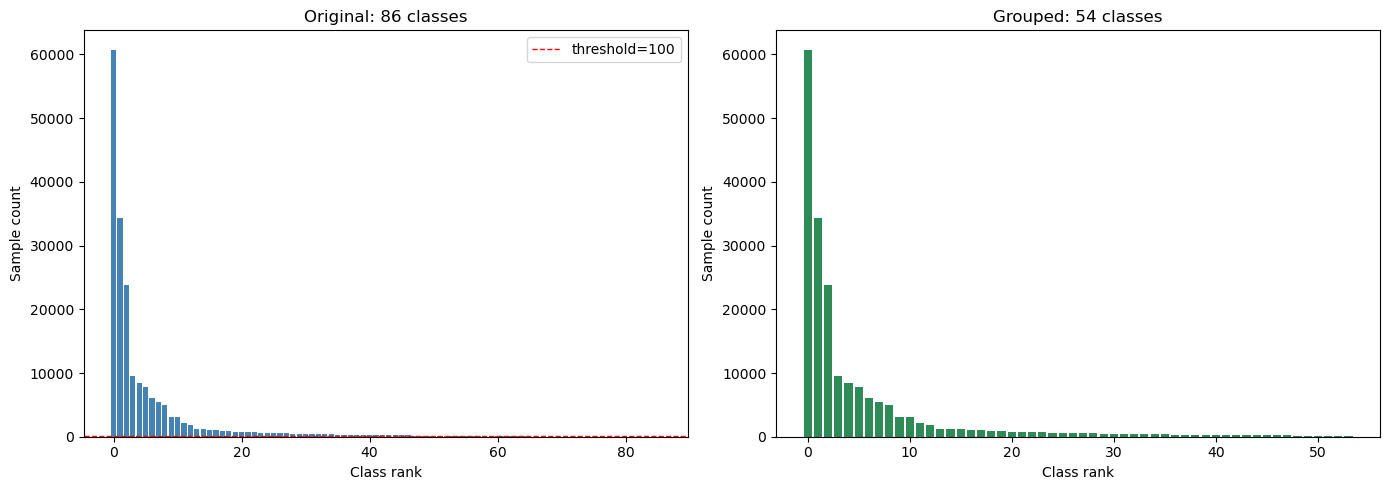

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

before = df['Y'].value_counts().sort_values(ascending=False)
axes[0].bar(range(len(before)), before.values, color='steelblue')
axes[0].set_title(f'Original: {len(before)} classes')
axes[0].set_xlabel('Class rank')
axes[0].set_ylabel('Sample count')
axes[0].axhline(y=100, color='red', linestyle='--', linewidth=1, label='threshold=100')
axes[0].legend()

after = df['Y_grouped'].value_counts().sort_values(ascending=False)
axes[1].bar(range(len(after)), after.values, color='seagreen')
axes[1].set_title(f'Grouped: {len(after)} classes')
axes[1].set_xlabel('Class rank')
axes[1].set_ylabel('Sample count')

plt.tight_layout()
plt.savefig('../models/class_distribution_before_after.png', dpi=150)
plt.show()


## Save for the next notebook

In [18]:
df.to_pickle('../data/df_grouped.pkl')
print("Saved ../data/df_grouped.pkl")


Saved ../data/df_grouped.pkl
